<a href="https://colab.research.google.com/github/jazapana/CMPE206-TCP-vs-UDP-Performance-Project/blob/small-large-file-transfer-experiments/TCP_vs_UDP_Transfer_Size.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Uploading CSV file code from: https://www.geeksforgeeks.org/machine-learning/ways-to-import-csv-files-in-google-colab/

from google.colab import files
uploaded = files.upload()

Saving transfer-1mb-output.csv to transfer-1mb-output.csv
Saving transfer-2mb-output.csv to transfer-2mb-output.csv
Saving transfer-10kb-output.csv to transfer-10kb-output.csv
Saving transfer-100kb-output.csv to transfer-100kb-output.csv


In [ ]:
import pandas as pd
import io

df_10kb = pd.read_csv(io.BytesIO(uploaded['transfer-10kb-output.csv']))
print(df_10kb)

  Protocol SourceAddress DestinationAddress  SourcePort  DestinationPort  \
0      TCP      10.1.1.1           10.1.2.2       49153                7   
1      UDP      10.1.3.1           10.1.2.2       49153                9   

   TxPackets  RxPackets  LostPackets  TxBytes  RxBytes  ThroughputKbps  \
0         13         13            0    10920    10920         1352.31   
1         10         10            0    10520    10520         1931.53   

   MeanDelayMs  MeanJitterMs  
0      5.85821         0.412  
1      5.68640         0.000  


In [ ]:
df_100kb = pd.read_csv(io.BytesIO(uploaded['transfer-100kb-output.csv']))
print(df_100kb)

  Protocol SourceAddress DestinationAddress  SourcePort  DestinationPort  \
0      TCP      10.1.1.1           10.1.2.2       49153                7   
1      UDP      10.1.3.1           10.1.2.2       49153                9   

   TxPackets  RxPackets  LostPackets  TxBytes  RxBytes  ThroughputKbps  \
0        101        101            0   105608   105608         1948.04   
1         98         98            0   103096   103096         1998.61   

   MeanDelayMs  MeanJitterMs  
0      6.46549       0.04944  
1      5.68640       0.00000  


In [ ]:
df_1mb = pd.read_csv(io.BytesIO(uploaded['transfer-1mb-output.csv']))
print(df_1mb)

  Protocol SourceAddress DestinationAddress  SourcePort  DestinationPort  \
0      TCP      10.1.1.1           10.1.2.2       49153                7   
1      UDP      10.1.3.1           10.1.2.2       49153                9   

   TxPackets  RxPackets  LostPackets  TxBytes  RxBytes  ThroughputKbps  \
0        980        980            0  1051412  1051412         2041.33   
1        977        977            0  1027804  1027804         2005.73   

   MeanDelayMs  MeanJitterMs  
0      6.54596      0.005054  
1      5.68640      0.000000  


In [ ]:
df_2mb = pd.read_csv(io.BytesIO(uploaded['transfer-2mb-output.csv']))
print(df_2mb)

  Protocol SourceAddress DestinationAddress  SourcePort  DestinationPort  \
0      TCP      10.1.1.1           10.1.2.2       49153                7   
1      UDP      10.1.3.1           10.1.2.2       49153                9   

   TxPackets  RxPackets  LostPackets  TxBytes  RxBytes  ThroughputKbps  \
0       1957       1957            0  2102664  2102664         2046.80   
1       1954       1954            0  2055608  2055608         2006.13   

   MeanDelayMs  MeanJitterMs  
0      6.55057      0.002532  
1      5.68640      0.000000  


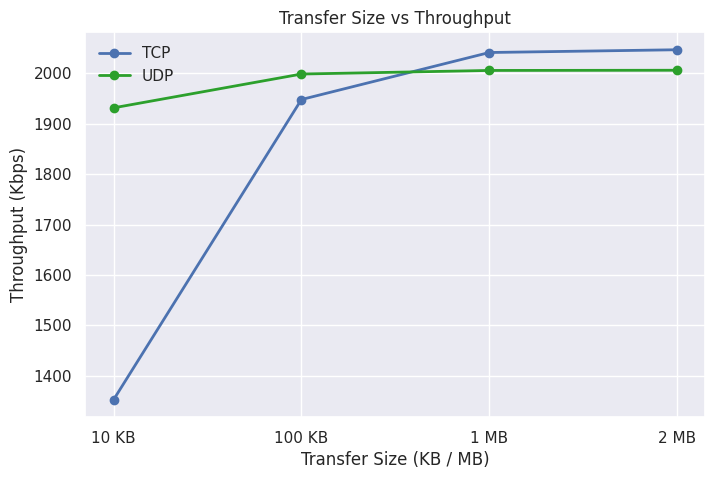

In [ ]:
# Matplotlib Line Chart code from: https://www.geeksforgeeks.org/python/line-chart-in-matplotlib-python/
# Matplotlib Custom X-Axis Ticks code from: https://www.geeksforgeeks.org/python/matplotlib-pyplot-xticks-in-python/
# Seaborn code from: https://www.geeksforgeeks.org/data-visualization/plotting-with-seaborn-and-matplotlib/
# Remove Legend Border code from: https://www.geeksforgeeks.org/python/remove-the-legend-border-in-matplotlib/

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

sns.set_theme(style="darkgrid")

file_sizes = ["10 KB", "100 KB", "1 MB", "2 MB"]
x = np.arange(len(file_sizes))

# Throughput
tcp_throughput = [
    df_10kb[df_10kb["Protocol"] == "TCP"]["ThroughputKbps"].values[0],
    df_100kb[df_100kb["Protocol"] == "TCP"]["ThroughputKbps"].values[0],
    df_1mb[df_1mb["Protocol"] == "TCP"]["ThroughputKbps"].values[0],
    df_2mb[df_2mb["Protocol"] == "TCP"]["ThroughputKbps"].values[0]
]

udp_throughput = [
    df_10kb[df_10kb["Protocol"] == "UDP"]["ThroughputKbps"].values[0],
    df_100kb[df_100kb["Protocol"] == "UDP"]["ThroughputKbps"].values[0],
    df_1mb[df_1mb["Protocol"] == "UDP"]["ThroughputKbps"].values[0],
    df_2mb[df_2mb["Protocol"] == "UDP"]["ThroughputKbps"].values[0]
]

plt.figure(figsize=(8, 5))
plt.plot(x, tcp_throughput, marker='o', linewidth=2, label='TCP')
plt.plot(x, udp_throughput, marker='o', color='tab:green', linewidth=2, label='UDP')
plt.xticks(x, file_sizes)
plt.grid(True)
plt.xlabel("Transfer Size (KB / MB)")
plt.ylabel("Throughput (Kbps)")
plt.title("Transfer Size vs Throughput")
plt.legend(frameon=False)
plt.show()

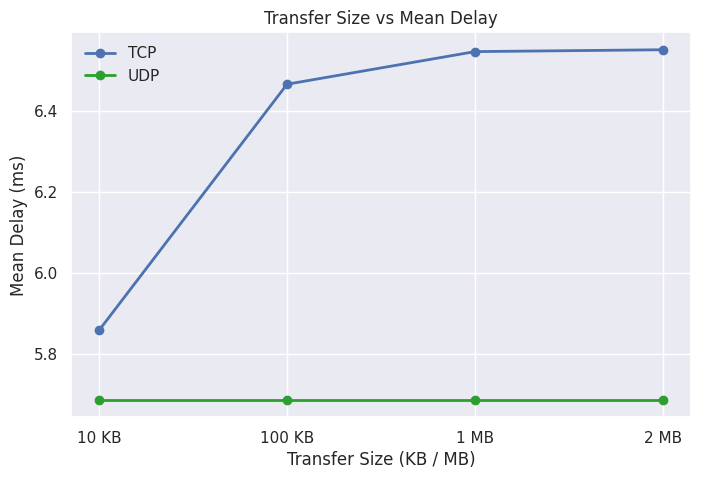

In [ ]:
# Delay
tcp_delay = [
    df_10kb[df_10kb["Protocol"] == "TCP"]["MeanDelayMs"].values[0],
    df_100kb[df_100kb["Protocol"] == "TCP"]["MeanDelayMs"].values[0],
    df_1mb[df_1mb["Protocol"] == "TCP"]["MeanDelayMs"].values[0],
    df_2mb[df_2mb["Protocol"] == "TCP"]["MeanDelayMs"].values[0]
]

udp_delay = [
    df_10kb[df_10kb["Protocol"] == "UDP"]["MeanDelayMs"].values[0],
    df_100kb[df_100kb["Protocol"] == "UDP"]["MeanDelayMs"].values[0],
    df_1mb[df_1mb["Protocol"] == "UDP"]["MeanDelayMs"].values[0],
    df_2mb[df_2mb["Protocol"] == "UDP"]["MeanDelayMs"].values[0]
]

plt.figure(figsize=(8, 5))
plt.plot(x, tcp_delay, marker='o', linewidth=2, label='TCP')
plt.plot(x, udp_delay, marker='o', color='tab:green', linewidth=2, label='UDP')
plt.xticks(x, file_sizes)
plt.grid(True)
plt.xlabel("Transfer Size (KB / MB)")
plt.ylabel("Mean Delay (ms)")
plt.title("Transfer Size vs Mean Delay")
plt.legend(frameon=False)
plt.show()

In [ ]:
# Create Dataframe from List using Zip code from: https://www.geeksforgeeks.org/python/create-pandas-dataframe-from-lists-using-zip/

# Packet Loss
packet_loss_data = []

sizes = ["10 KB", "100 KB", "1 MB", "2 MB"]

for size, df in zip(sizes, [df_10kb, df_100kb, df_1mb, df_2mb]):
    tcp_loss = df[df["Protocol"] == "TCP"]["LostPackets"].values[0]
    udp_loss = df[df["Protocol"] == "UDP"]["LostPackets"].values[0]

    packet_loss_data.append([size, "TCP", tcp_loss])
    packet_loss_data.append([size, "UDP", udp_loss])

packet_loss_df = pd.DataFrame(packet_loss_data, columns=["Transfer Size", "Protocol", "LostPackets"])

packet_loss_df

,Transfer Size,Protocol,LostPackets
0,10 KB,TCP,0
1,10 KB,UDP,0
2,100 KB,TCP,0
3,100 KB,UDP,0
4,1 MB,TCP,0
5,1 MB,UDP,0
6,2 MB,TCP,0
7,2 MB,UDP,0


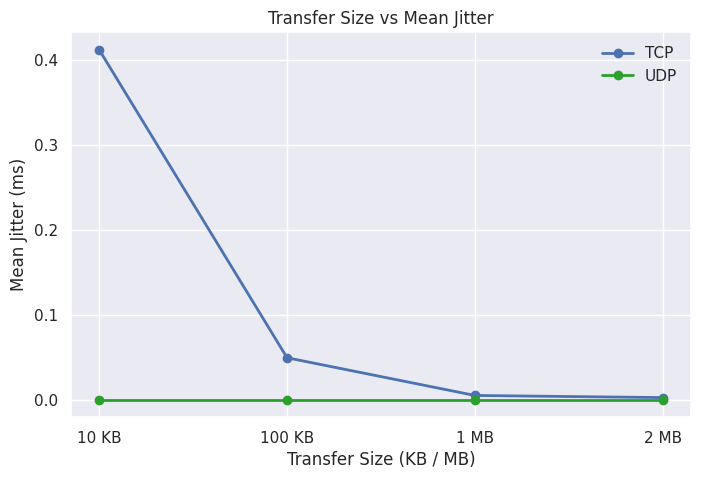

In [ ]:
# Jitter
tcp_jitter = [
    df_10kb[df_10kb["Protocol"] == "TCP"]["MeanJitterMs"].values[0],
    df_100kb[df_100kb["Protocol"] == "TCP"]["MeanJitterMs"].values[0],
    df_1mb[df_1mb["Protocol"] == "TCP"]["MeanJitterMs"].values[0],
    df_2mb[df_2mb["Protocol"] == "TCP"]["MeanJitterMs"].values[0]
]

udp_jitter = [
    df_10kb[df_10kb["Protocol"] == "UDP"]["MeanJitterMs"].values[0],
    df_100kb[df_100kb["Protocol"] == "UDP"]["MeanJitterMs"].values[0],
    df_1mb[df_1mb["Protocol"] == "UDP"]["MeanJitterMs"].values[0],
    df_2mb[df_2mb["Protocol"] == "UDP"]["MeanJitterMs"].values[0]
]

plt.figure(figsize=(8, 5))
plt.plot(x, tcp_jitter, marker='o', linewidth=2, label='TCP')
plt.plot(x, udp_jitter, marker='o', color='tab:green', linewidth=2, label='UDP')
plt.xticks(x, file_sizes)
plt.grid(True)
plt.xlabel("Transfer Size (KB / MB)")
plt.ylabel("Mean Jitter (ms)")
plt.title("Transfer Size vs Mean Jitter")
plt.legend(frameon=False)
plt.show()

In [ ]:
fairness_transfer = 4*[0]

dfs = [df_10kb, df_100kb, df_1mb, df_2mb]

for i in range(4):
  x1 = dfs[i].iloc[0]['ThroughputKbps']
  x2 = dfs[i].iloc[1]['ThroughputKbps']
  fairness_transfer[i] = (x1 + x2)**2 / (2*(x1**2 + x2**2))

fairness_transfer_df = pd.DataFrame({
    "Transfer Size": ["10 KB", "100 KB", "1 MB", "2 MB"],
    "Fairness": fairness_transfer
})

fairness_transfer_df

,Transfer Size,Fairness
0,10 KB,0.969827
1,100 KB,0.999836
2,1 MB,0.999923
3,2 MB,0.999899
